In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 764.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 97.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import zipfile

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
zip_path = "/content/fer.zip"
extract_path = "/content/fer_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

train_dir = os.path.join(extract_path, "train")
test_dir = os.path.join(extract_path, "test")

In [ ]:
train_dir = "/content/fer_data/train"
test_dir = "/content/fer_data/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data_full = datagen.flow_from_directory(
    train_dir,
    target_size=(64,64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(64,64),
    batch_size=32,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_data_full.class_indices.keys())
num_classes = len(class_names)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
cnn = Sequential()

# Block 1
cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.25))

# Block 2
cnn.add(Conv2D(64, (3,3), activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.25))

# Block 3
cnn.add(Conv2D(128, (3,3), activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.3))

cnn.add(Flatten())

# Temporary classifier (for training only)
cnn.add(Dense(256, activation='relu'))
cnn.add(Dropout(0.5))
cnn.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,271 (4.86 MB)

 Trainable params: 1,274,823 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = cnn.fit(
    train_data_full,
    epochs=25
)

Epoch 1/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 159s 175ms/step - accuracy: 0.2774 - loss: 1.8443
Epoch 2/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 155s 172ms/step - accuracy: 0.3579 - loss: 1.6356
Epoch 3/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 155s 173ms/step - accuracy: 0.3950 - loss: 1.5472
Epoch 4/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 157s 174ms/step - accuracy: 0.4191 - loss: 1.4954
Epoch 5/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.4434 - loss: 1.4292
Epoch 6/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.4611 - loss: 1.3959
Epoch 7/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 157s 174ms/step - accuracy: 0.4801 - loss: 1.3474
Epoch 8/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.4963 - loss: 1.3129
Epoch 9/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.5083 - loss: 1.2764
Epoch 10/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 157s 175ms/step - accuracy: 0.5222 - loss: 1.2459
Epoch 11/25
898/898 ━━━━━━━━━━━━━━━━━━━━ 157s 175ms/step - accuracy: 0.5328 - loss: 1.2225
Epoch 12

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


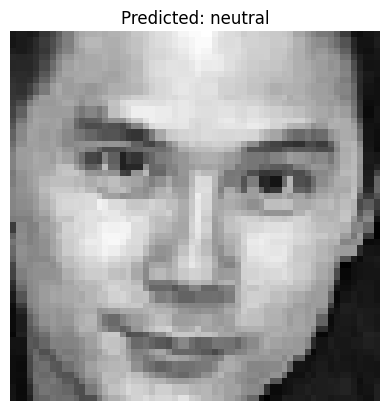

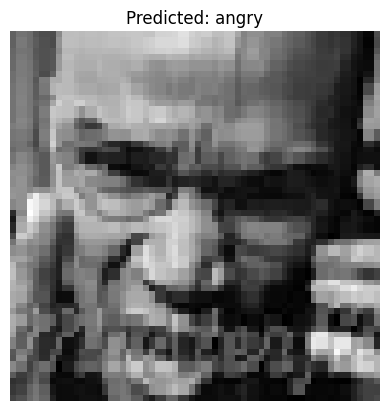

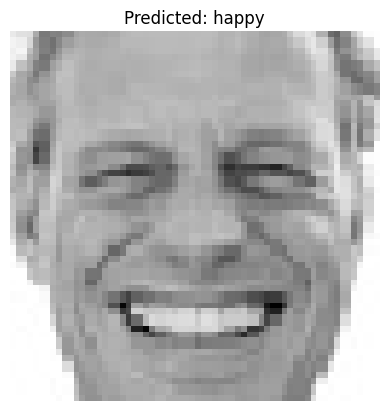

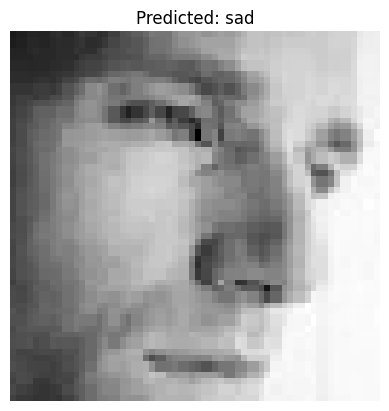

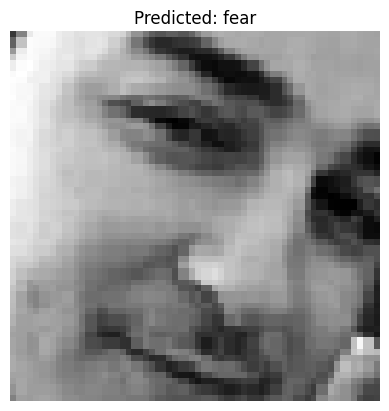

In [ ]:
# pick few images
x_batch, y_batch = next(train_data_full)

preds = cnn.predict(x_batch[:5])

for i in range(5):
    plt.imshow(x_batch[i].reshape(64,64), cmap='gray')
    plt.title(f"Predicted: {class_names[np.argmax(preds[i])]}")
    plt.axis('off')
    plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# ---------- Make sure test generator is aligned ----------
# If needed, recreate test generator with shuffle=False before this block

# ---------- Predictions ----------
# Training accuracy (on the full train generator)
train_loss, train_acc = cnn.evaluate(train_data_full, verbose=0)

# Test predictions
test_probs = cnn.predict(test_data, verbose=0)
test_pred  = np.argmax(test_probs, axis=1)
y_true     = test_data.classes

# ---------- Test accuracy ----------
test_acc = np.mean(test_pred == y_true)

# ---------- Overfit gap ----------
gap = (train_acc - test_acc) * 100

# ---------- Class-wise accuracy ----------
cm = confusion_matrix(y_true, test_pred)

class_wise = {}
for i, cls in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i][i]
    acc = (correct / total) * 100 if total > 0 else 0
    class_wise[cls] = (acc, correct, total)

# ---------- Classification report ----------
report = classification_report(y_true, test_pred, target_names=class_names, digits=2)

# ---------- Pretty print ----------
print("="*50)
print("CNN EVALUATION REPORT")
print("="*50)
print(f"Found {len(y_true)} images belonging to {len(class_names)} classes.\n")

print(f"  CNN Training Accuracy  : {train_acc*100:.2f}%")
print(f"  CNN Test Accuracy      : {test_acc*100:.2f}%")
print(f"  Gap (Overfit indicator): {gap:.2f}%\n")

print("  Verdict:")
if gap < 5:
    print("  CNN is NOT overfitting — gap is less than 5%")
else:
    print("  CNN may be overfitting — gap is greater than 5%")

print("\n" + "-"*50)
print("  Class-wise CNN Accuracy:")
print("-"*50)

for cls, (acc, correct, total) in class_wise.items():
    print(f"  {cls:<12}: {acc:.2f}%  ({correct}/{total})")

print("\n" + "-"*50)
print("  Classification Report:")
print("-"*50)
print(report)

print("\n" + "="*50)

CNN EVALUATION REPORT
Found 7178 images belonging to 7 classes.

  CNN Training Accuracy  : 82.34%
  CNN Test Accuracy      : 59.71%
  Gap (Overfit indicator): 22.63%

  Verdict:
  CNN may be overfitting — gap is greater than 5%

--------------------------------------------------
  Class-wise CNN Accuracy:
--------------------------------------------------
  angry       : 44.57%  (427/958)
  disgust     : 42.34%  (47/111)
  fear        : 34.67%  (355/1024)
  happy       : 84.39%  (1497/1774)
  neutral     : 60.58%  (747/1233)
  sad         : 46.99%  (586/1247)
  surprise    : 75.45%  (627/831)

--------------------------------------------------
  Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

       angry       0.55      0.45      0.49       958
     disgust       0.81      0.42      0.56       111
        fear       0.45      0.35      0.39      1024
       happy       0.75      0.84      0.80      1774


In [ ]:
feature_extractor = Model(
    inputs=cnn.inputs,
    outputs=cnn.layers[-3].output   # output before Dense layers
)

In [ ]:
train_features = feature_extractor.predict(train_data_full)
train_labels = train_data_full.classes

test_features = feature_extractor.predict(test_data)
test_labels = test_data.classes

898/898 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step


In [ ]:
from tensorflow.keras.utils import to_categorical

X_train, X_val, y_train, y_val = train_test_split(
    train_features,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=42
)

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)
y_test = to_categorical(test_labels, num_classes)

In [ ]:
ann = Sequential()

ann.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
ann.add(Dropout(0.6))   # 🔥 increased

ann.add(Dense(128, activation='relu'))
ann.add(Dropout(0.5))   # 🔥 increased

ann.add(Dense(num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
ann.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,591 (389.03 KB)

 Trainable params: 99,591 (389.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ann = ann.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')]
)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5703 - loss: 1.3238 - val_accuracy: 0.7726 - val_loss: 0.6995
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7176 - loss: 0.7905 - val_accuracy: 0.8044 - val_loss: 0.5725
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7621 - loss: 0.6714 - val_accuracy: 0.8178 - val_loss: 0.5149
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7848 - loss: 0.6081 - val_accuracy: 0.8213 - val_loss: 0.4861
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8005 - loss: 0.5664 - val_accuracy: 0.8248 - val_loss: 0.4705
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8101 - loss: 0.5370 - val_accuracy: 0.8335 - val_loss: 0.4565
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8164 - loss: 0.5121 - val_accuracy: 0.8325 - val_loss: 0.4520
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8233 - loss: 0.4929 - val_accuracy: 0.

In [ ]:
test_pred = np.argmax(ann.predict(test_features), axis=1)
test_acc = accuracy_score(test_labels, test_pred)

print("Final Test Accuracy:", test_acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step
Final Test Accuracy: 0.5973808860406798


In [ ]:
def show_cm(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, target_names=class_names))

718/718 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step


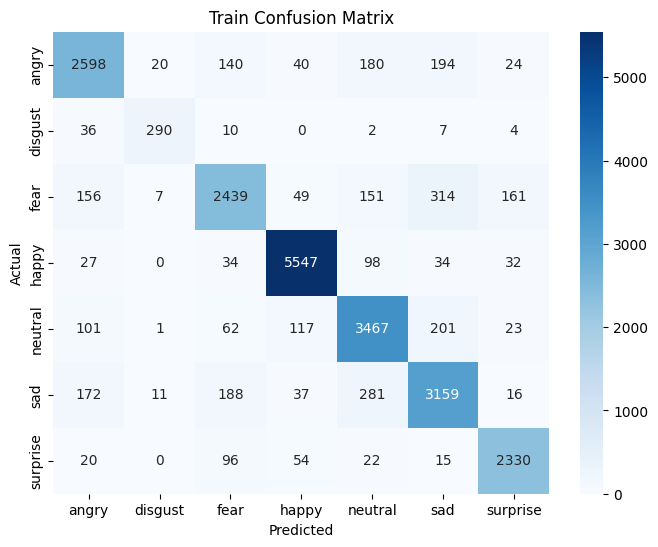


Classification Report:
               precision    recall  f1-score   support

       angry       0.84      0.81      0.82      3196
     disgust       0.88      0.83      0.86       349
        fear       0.82      0.74      0.78      3277
       happy       0.95      0.96      0.96      5772
     neutral       0.83      0.87      0.85      3972
         sad       0.81      0.82      0.81      3864
    surprise       0.90      0.92      0.91      2537

    accuracy                           0.86     22967
   macro avg       0.86      0.85      0.85     22967
weighted avg       0.86      0.86      0.86     22967



In [ ]:
train_pred = np.argmax(ann.predict(X_train), axis=1)
y_train_true = np.argmax(y_train, axis=1)
show_cm(y_train_true, train_pred, class_names, "Train Confusion Matrix")

180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step


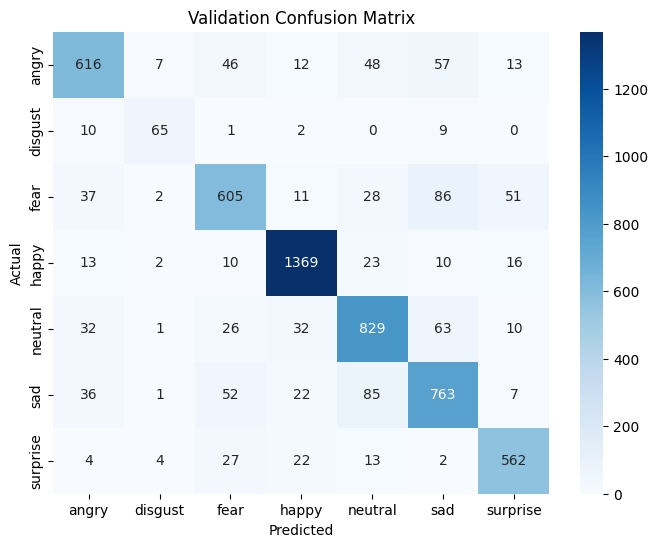


Classification Report:
               precision    recall  f1-score   support

       angry       0.82      0.77      0.80       799
     disgust       0.79      0.75      0.77        87
        fear       0.79      0.74      0.76       820
       happy       0.93      0.95      0.94      1443
     neutral       0.81      0.83      0.82       993
         sad       0.77      0.79      0.78       966
    surprise       0.85      0.89      0.87       634

    accuracy                           0.84      5742
   macro avg       0.82      0.82      0.82      5742
weighted avg       0.84      0.84      0.84      5742



In [ ]:
val_pred   = np.argmax(ann.predict(X_val), axis=1)
y_val_true   = np.argmax(y_val, axis=1)
show_cm(y_val_true,   val_pred,   class_names, "Validation Confusion Matrix")

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step


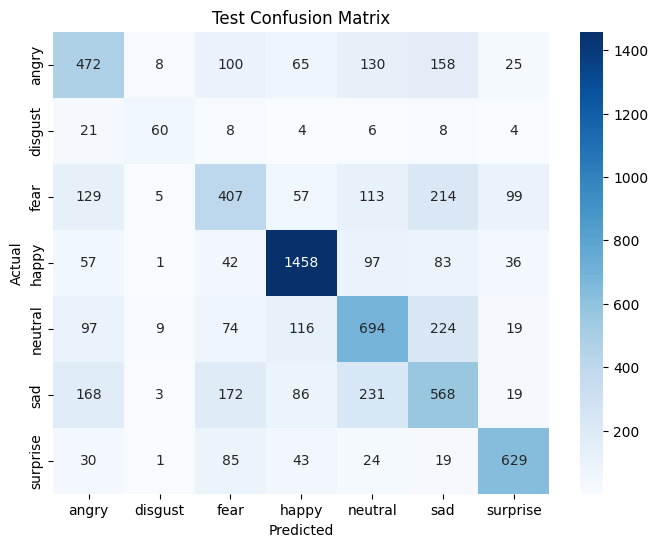


Classification Report:
               precision    recall  f1-score   support

       angry       0.48      0.49      0.49       958
     disgust       0.69      0.54      0.61       111
        fear       0.46      0.40      0.43      1024
       happy       0.80      0.82      0.81      1774
     neutral       0.54      0.56      0.55      1233
         sad       0.45      0.46      0.45      1247
    surprise       0.76      0.76      0.76       831

    accuracy                           0.60      7178
   macro avg       0.60      0.58      0.58      7178
weighted avg       0.59      0.60      0.60      7178



In [ ]:
test_pred  = np.argmax(ann.predict(test_features), axis=1)
y_test_true  = test_labels  # already integers
show_cm(y_test_true,  test_pred,  class_names, "Test Confusion Matrix")

In [ ]:
import zipfile, os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ---------- CONFIG ----------
zip_path = "/content/test_images.zip"
extract_path = "/content/zip_images/"
img_size = 64
emotion_classes = ['angry','disgust','fear','happy','neutral','sad','surprise']

# ---------- EXTRACT ZIP ----------
if os.path.exists(extract_path):
    import shutil; shutil.rmtree(extract_path)
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

# ---------- LOAD IMAGES ----------
image_files = sorted([
    f for f in os.listdir(extract_path)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
])

print(f"Total images found: {len(image_files)}")

images_array = []

for img_name in image_files:
    img_path = os.path.join(extract_path, img_name)

    try:
        img = load_img(img_path,
                       target_size=(img_size, img_size),
                       color_mode='grayscale')

        img = img_to_array(img) / 255.0
        images_array.append(img)

    except:
        continue

images_array = np.array(images_array)

# ---------- CNN → ANN ----------
features = cnn.predict(images_array, verbose=0)
predictions = ann.predict(features, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)
confidence_scores = np.max(predictions, axis=1)

# ---------- DISPLAY GRID ----------
cols = 5
rows = (len(image_files) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i in range(len(image_files)):
    axes[i].imshow(images_array[i].squeeze(), cmap='gray')
    axes[i].set_title(
        f"{image_files[i][:12]}\n"
        f"{emotion_classes[predicted_labels[i]]}\n"
        f"{confidence_scores[i]*100:.1f}%",
        fontsize=8
    )
    axes[i].axis('off')

# hide extra slots
for j in range(len(image_files), len(axes)):
    axes[j].axis('off')

plt.suptitle("ZIP Emotion Prediction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------- DETAILED OUTPUT ----------
print("\nDetailed Results:")
print("-" * 50)

for i in range(len(image_files)):
    print(f"{image_files[i]:<25} => {emotion_classes[predicted_labels[i]]:<10} ({confidence_scores[i]*100:.1f}%)")